In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

In [5]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
# imputer -> missing data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [7]:
# Encode 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])

titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [8]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [9]:
X = titanic[features]
y = titanic[target]

In [10]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [11]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Decision Tree Model - no prunning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
y_pred = model.predict(X_test)

print("Accuracy = ", accuracy_score(y_test, y_pred))

Accuracy =  0.770949720670391


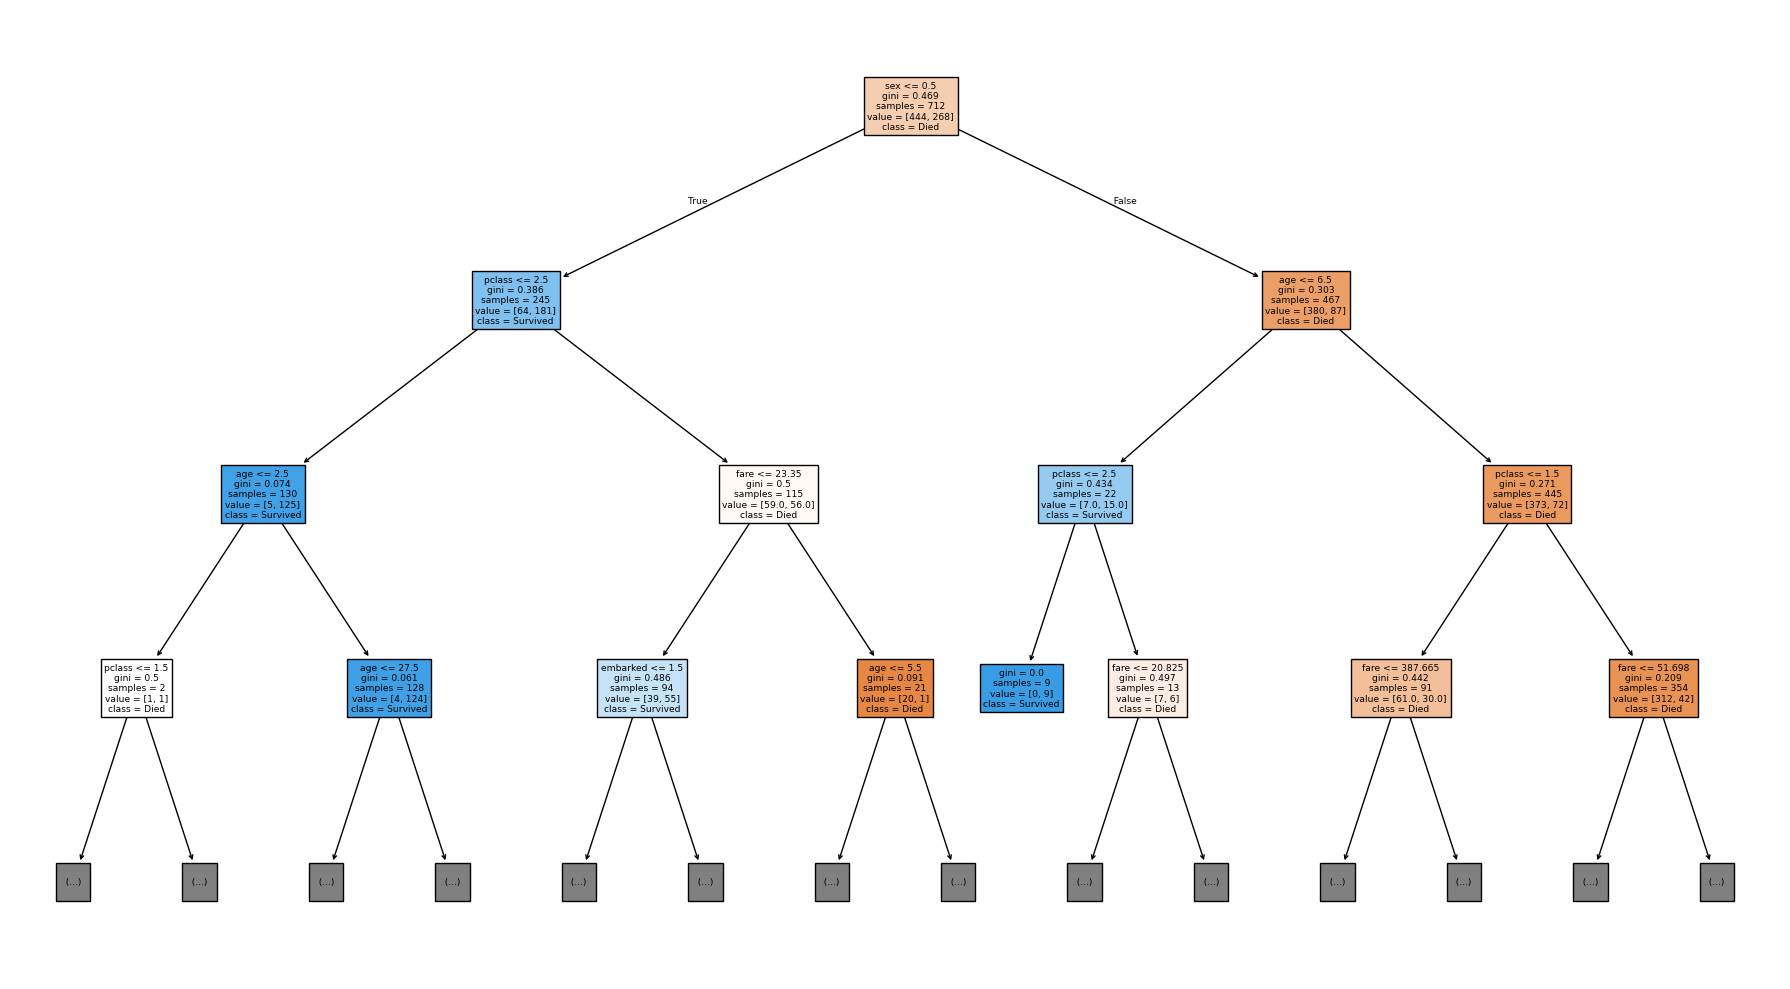

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=3
)

plt.tight_layout()
plt.show()

# Decision Training -> Pre-Pruning

for depth = 2, accuracy = 0.7653631284916201
for depth = 3, accuracy = 0.7988826815642458
for depth = 4, accuracy = 0.7988826815642458


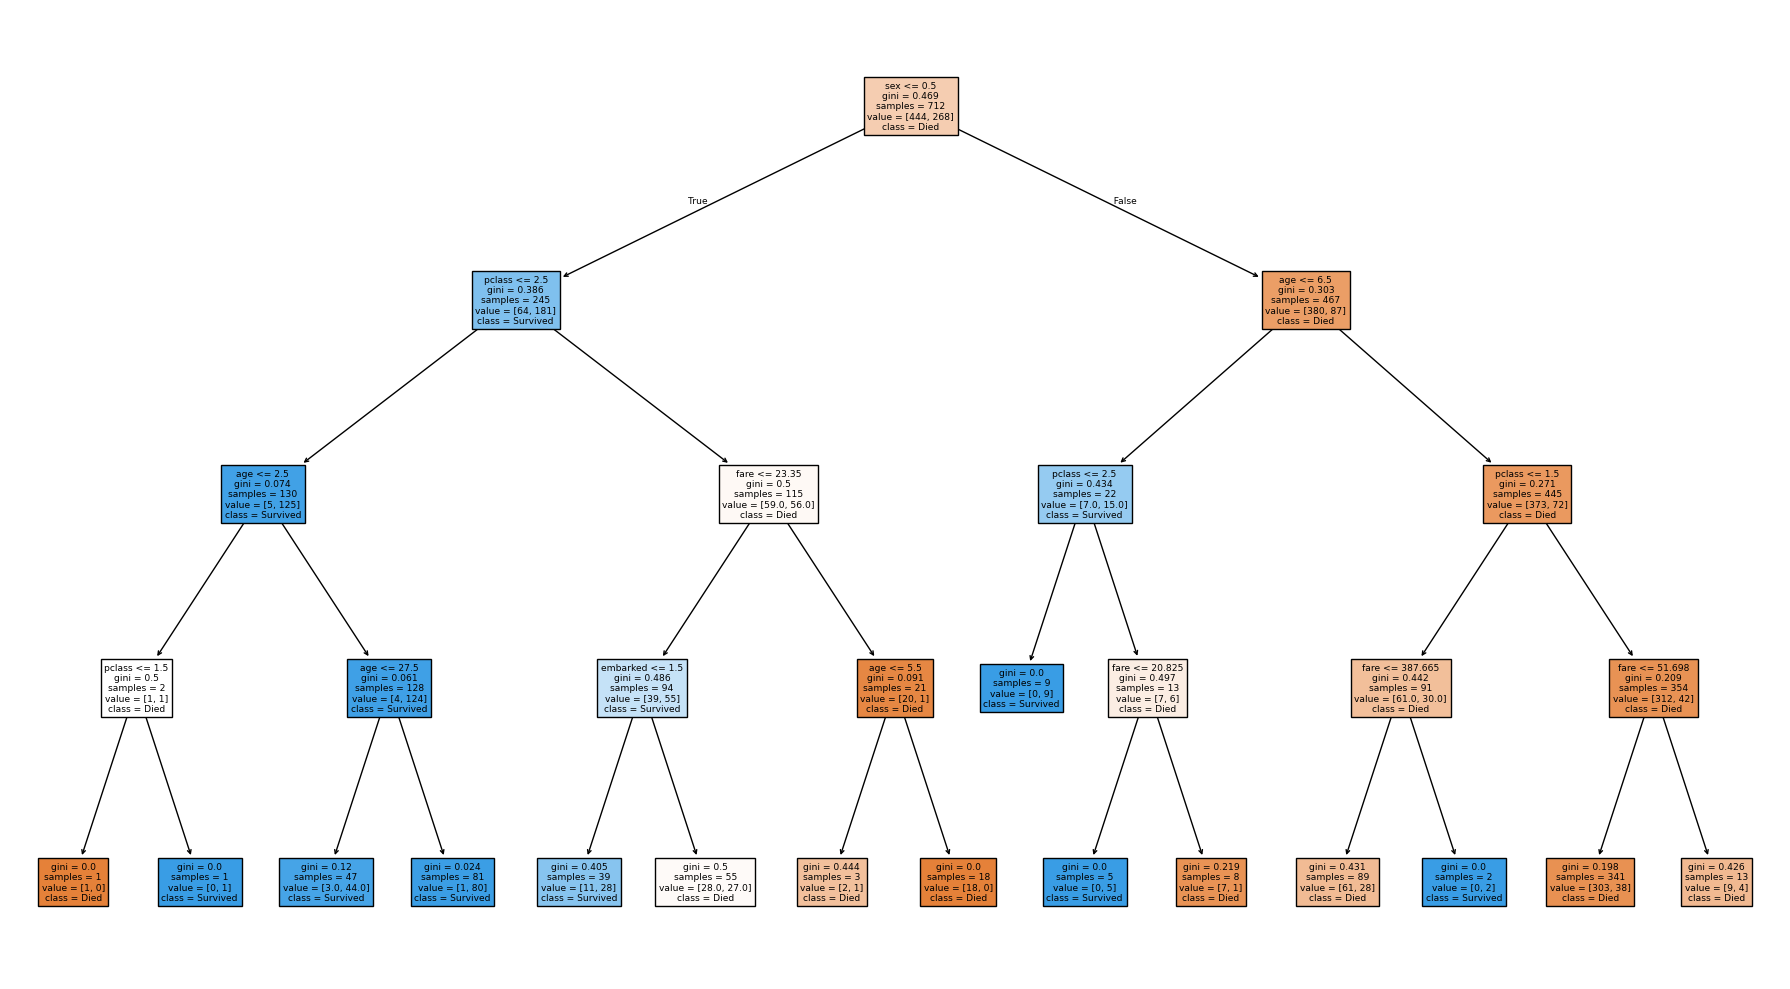

for depth = 5, accuracy = 0.7988826815642458
for depth = 6, accuracy = 0.7988826815642458
for depth = 7, accuracy = 0.8044692737430168
for depth = 8, accuracy = 0.7988826815642458
for depth = 9, accuracy = 0.7932960893854749
for depth = 10, accuracy = 0.7877094972067039
for depth = 11, accuracy = 0.7988826815642458


In [21]:
max_depths = [2,3,4,5,6,7,8,9,10,11]

for depth in max_depths:
    
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for depth = {depth}, accuracy = {acc}")

    if depth == 4:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True,
        )
        
        plt.tight_layout()
        plt.show()

for splits = 5, accuracy = 0.7988826815642458
for splits = 10, accuracy = 0.7988826815642458


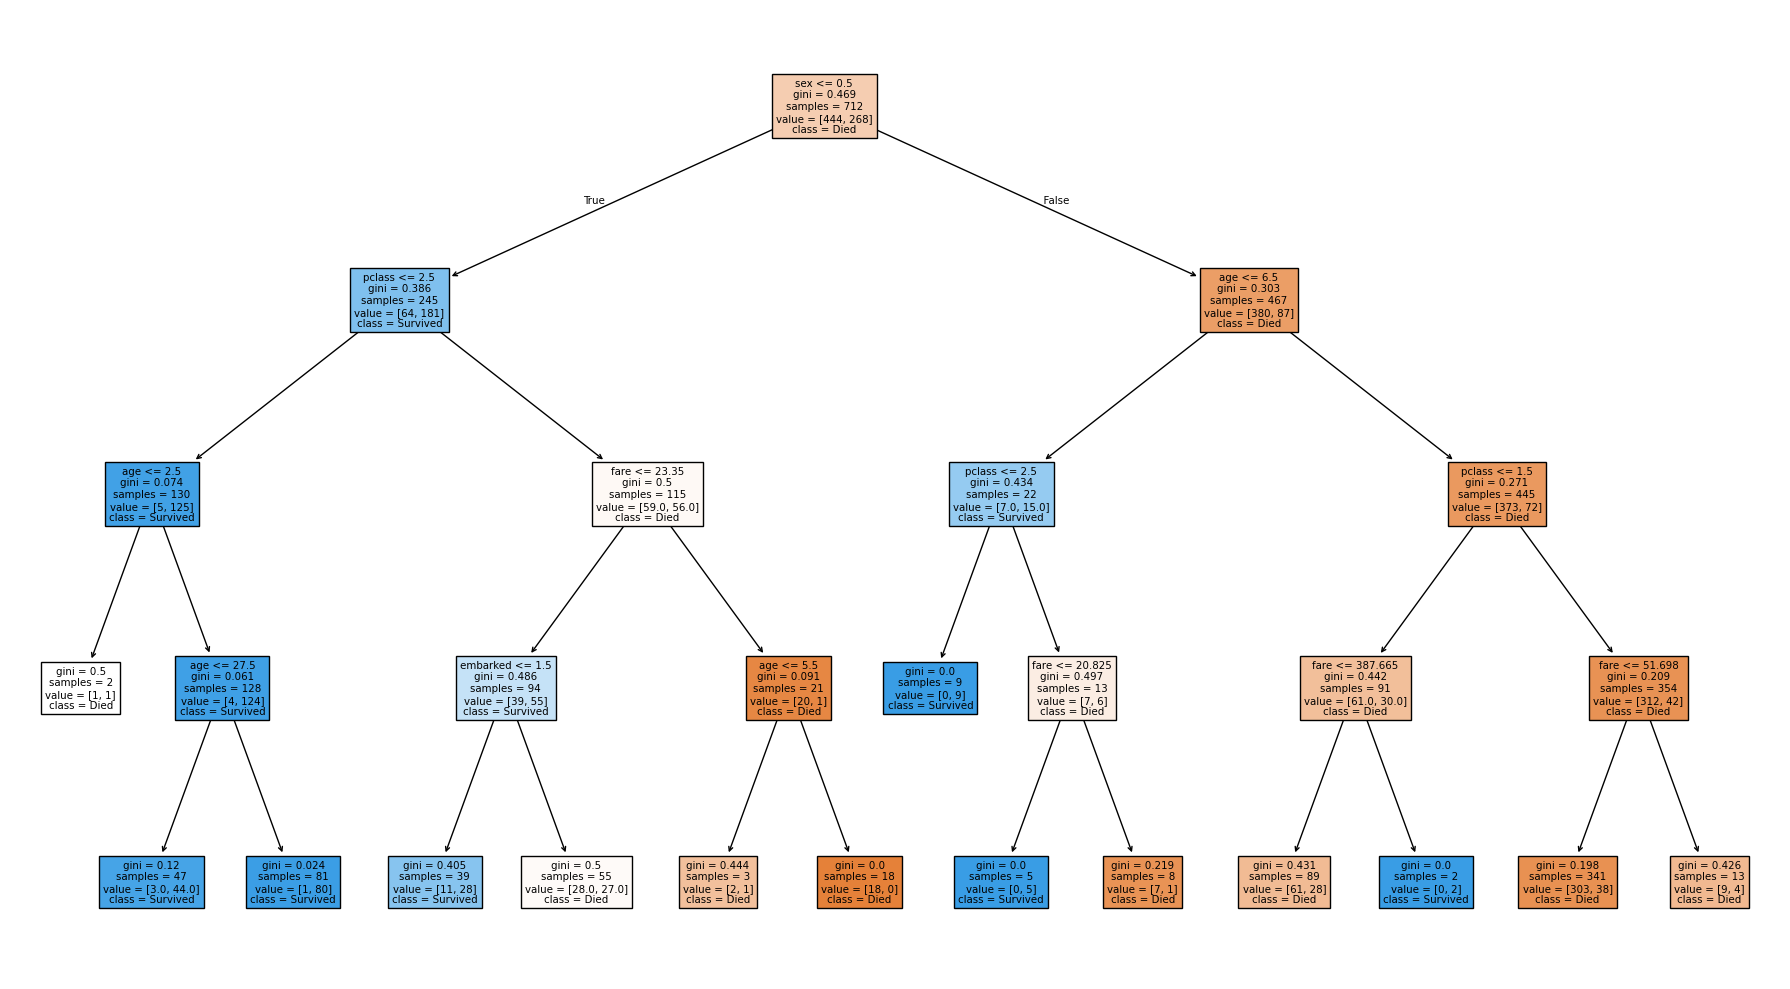

for splits = 15, accuracy = 0.7988826815642458
for splits = 20, accuracy = 0.7988826815642458
for splits = 25, accuracy = 0.7932960893854749
for splits = 30, accuracy = 0.7932960893854749


In [20]:
min_samples_splits = [5,10,15,20,25,30]

for split in min_samples_splits:
    
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for splits = {split}, accuracy = {acc}")

    if split == 10:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True,
        )
        
        plt.tight_layout()
        plt.show()

# Decision Training -> Post-Pruning

In [25]:
path = model.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.        , 0.00023408, 0.00025929, 0.00043866, 0.00053505,
       0.0005618 , 0.00062422, 0.0006679 , 0.00066799, 0.00081929,
       0.00089423, 0.00090815, 0.00092477, 0.00093633, 0.00093633,
       0.00103717, 0.00107401, 0.00108647, 0.0011236 , 0.0011236 ,
       0.0011236 , 0.00117041, 0.00117298, 0.00118823, 0.00122893,
       0.00124844, 0.00127566, 0.00130996, 0.00133761, 0.00137045,
       0.00143792, 0.00146301, 0.00156675, 0.00160434, 0.00166892,
       0.00186751, 0.00189607, 0.00210674, 0.00217042, 0.00234082,
       0.00241226, 0.00264274, 0.00269413, 0.00343771, 0.00356328,
       0.00547434, 0.0090554 , 0.01392951, 0.01592416, 0.03860535,
       0.13777998])

In [29]:
# Train our model for all alphas -> hyperparameter 

tree = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    tree.append((model, alpha))

In [33]:
best_acc = 0
best_alpha = 0

for model,alpha in tree:
    curr_acc = model.score(X_test, y_test)
    if(best_acc < curr_acc):
        best_acc = curr_acc
        best_alpha = alpha

print(f"Best alpha = {best_alpha}, acc = {best_acc}")

Best alpha = 0.0015667543564884488, acc = 0.8324022346368715


accuracy = 0.8324022346368715


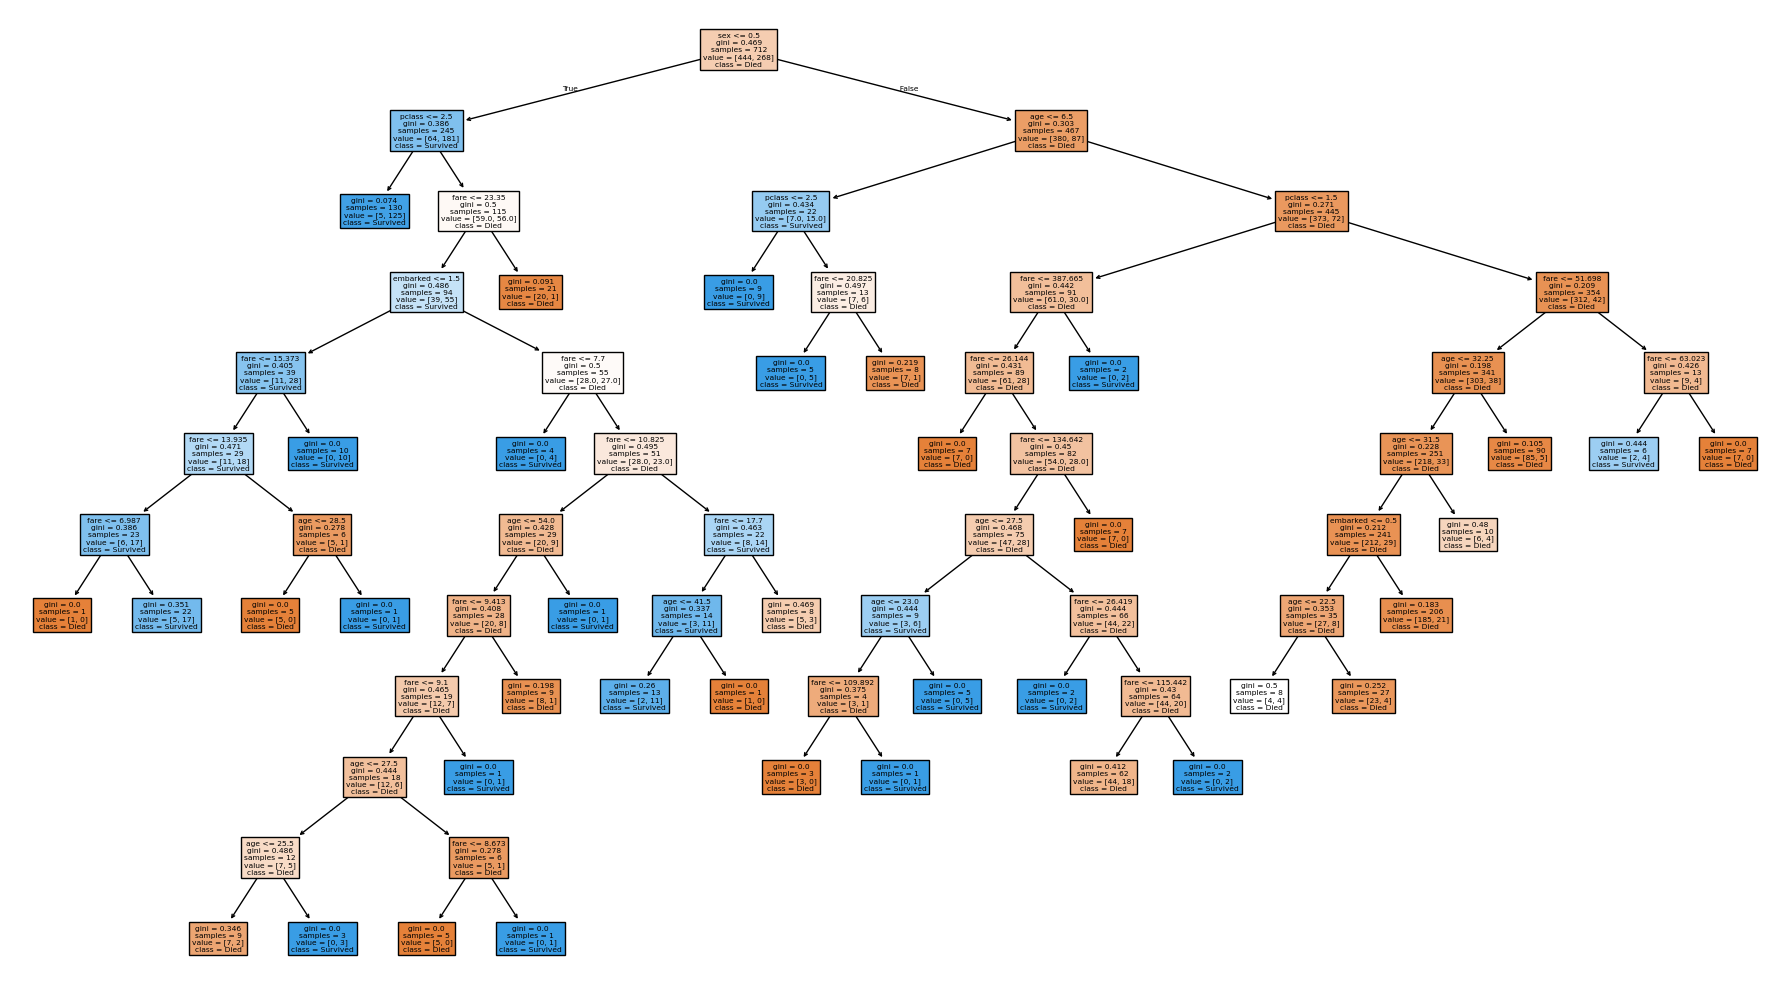

In [35]:
# Best alpha model

best_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)

print(f"accuracy = {best_model.score(X_test,y_test)}")

plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
)

plt.tight_layout()
plt.show()

accuracy = 0.7988826815642458


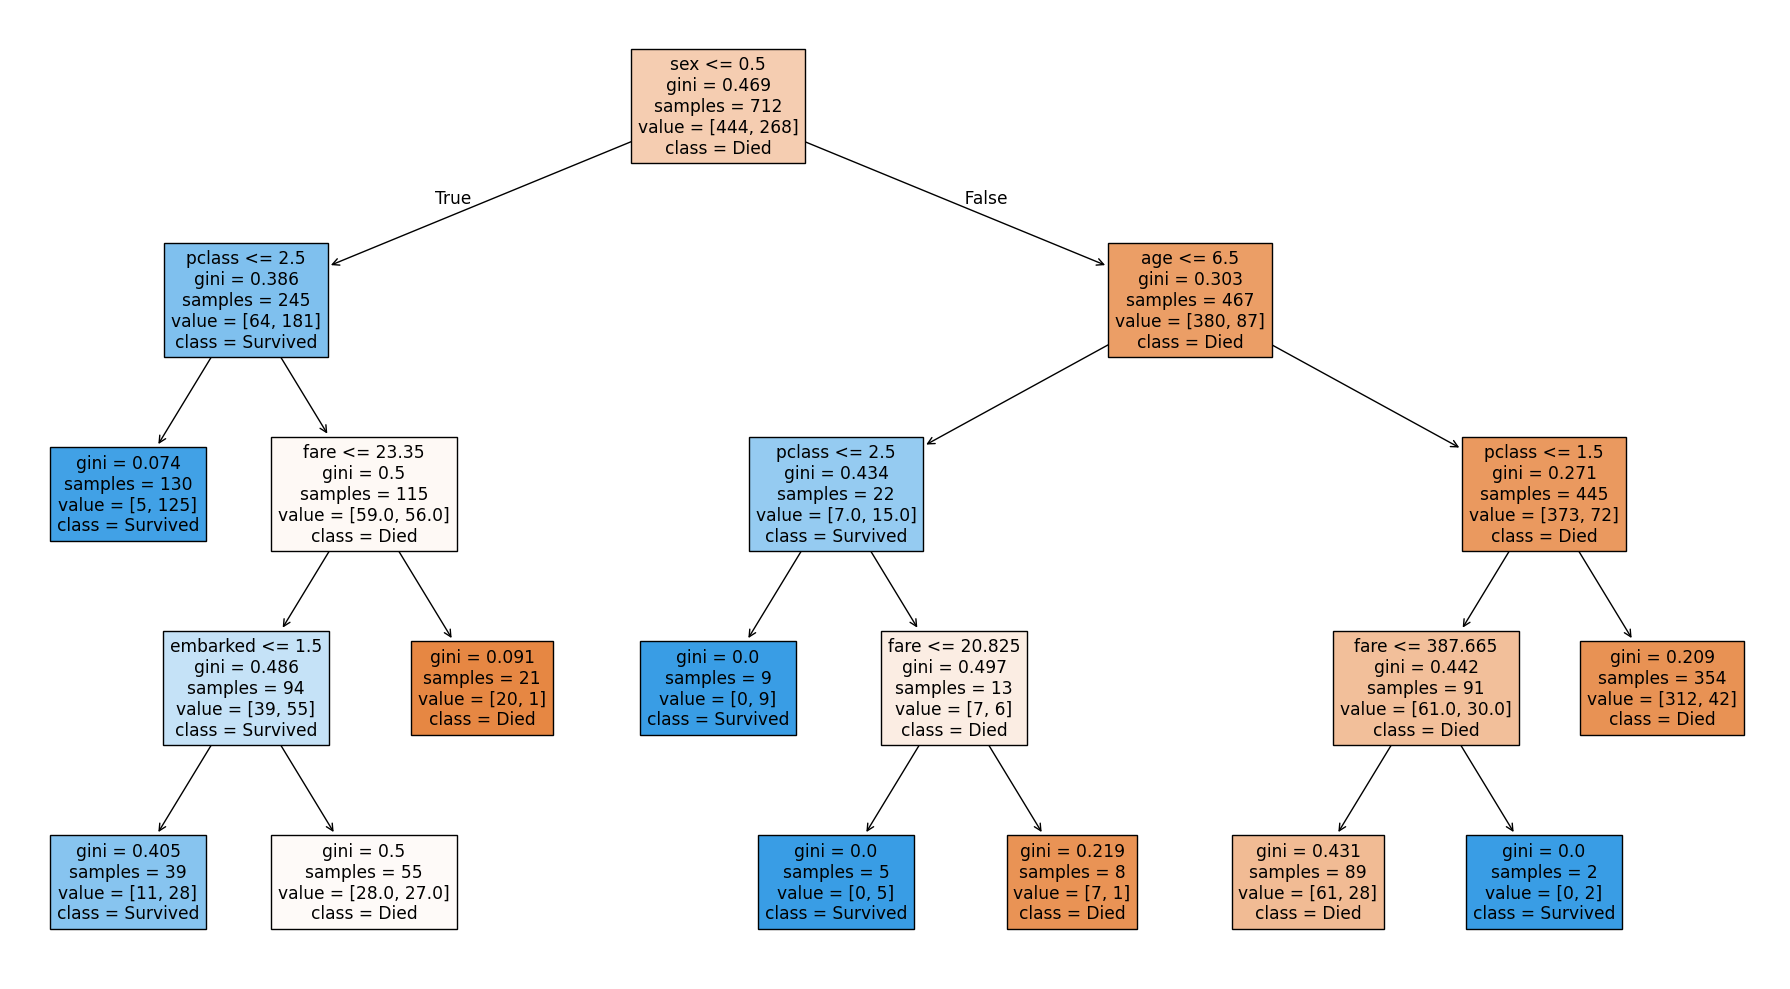

In [36]:
# We can also do pre and post together 

# Best alpha model

best_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha, max_depth=4)
best_model.fit(X_train, y_train)

print(f"accuracy = {best_model.score(X_test,y_test)}")

plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
)

plt.tight_layout()
plt.show()